Fundamentals of Deep Learning Models

# Lab 07-3: U-Net for Image Segmentation
## Exercise: Semantic image segmentation using U-Net

This exercise implements the **U-Net encoder–decoder architecture** (Section 7.7) for semantic segmentation on the Oxford-IIIT Pet dataset. The model follows the architecture illustrated in Figure 7.10, employing down-convolution blocks (encoder), a bottleneck block, and up-convolution blocks (decoder) with skip connections that concatenate encoder feature maps to decoder layers. The final output layer uses a softmax activation for pixel-wise class prediction (Section 7.7). A boundary-aware sample weighting strategy is applied during training to emphasize boundary pixels, inspired by the weighting approach described in Eq. (7.27).

**Note:** This implementation uses padded convolutions and batch normalization, which differ from the original U-Net formulation as noted in Section 7.7.

### Load libraries

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('TensorFlow Datasets version:', tfds.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# Check available GPU devices
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2
TensorFlow Datasets version: 4.9.9
Matplotlib version: 3.10.0
Num GPUs Available:  1


In [2]:
from PIL import ImageFile
from PIL import __version__ as pil_version
ImageFile.LOAD_TRUNCATED_IMAGES = True

print('PIL version:', pil_version)

PIL version: 11.3.0


### Prepare datasets

The **Oxford-IIIT Pet dataset** (from TensorFlow Datasets, Apache 2.0 license) contains 7,349 images of 37 pet breeds with pixel-level segmentation masks. Each mask pixel has one of three labels: object (pet body), background, and outline (boundary). The dataset is split into training, test, and validation sets.

In [3]:
# tfds works in both Eager and Graph modes
#tf.compat.v1.enable_eager_execution()
(ds_train, ds_test, ds_val), ds_info = tfds.load('oxford_iiit_pet', split=['train', 'test[:50%]', 'test[50%:]'],
                                                 batch_size=None, shuffle_files=True, # as_supervised=True,
                                                 with_info=True, download=True,)

print(ds_info.features)
print(ds_info.splits)
print(ds_info.splits['train'].num_examples)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.07O5M6_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.07O5M6_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
FeaturesDict({
    'file_name': Text(shape=(), dtype=string),
    'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=37),
    'segmentation_mask': Image(shape=(None, None, 1), dtype=uint8),
    'species': ClassLabel(shape=(), dtype=int64, num_classes=2),
})
{'train': <SplitInfo num_examples=3680, num_shards=4>, 'test': <SplitInfo num_examples=3669, num_shards=4>}
3680


In [4]:
n_channels = ds_info.features['image'].shape[-1]

classes = ds_info.features['label'].names
species = ds_info.features['species'].names
n_classes = ds_info.features['label'].num_classes

n_train = len(ds_train)
n_test = len(ds_test)
n_val = len(ds_val)

print(n_train,n_test,n_val)

3680 1834 1835


In [5]:
idx = np.random.randint(n_train-1)

# Get one sample of dataset
for sample in ds_train.skip(idx).take(1):
    fname = sample['file_name']
    image = sample['image']
    label = sample['label']
    smask = sample['segmentation_mask']
    specs = sample['species']

list(sample)

['file_name', 'head_bbox', 'image', 'label', 'segmentation_mask', 'species']

### Show a sample data

Dog - newfoundland


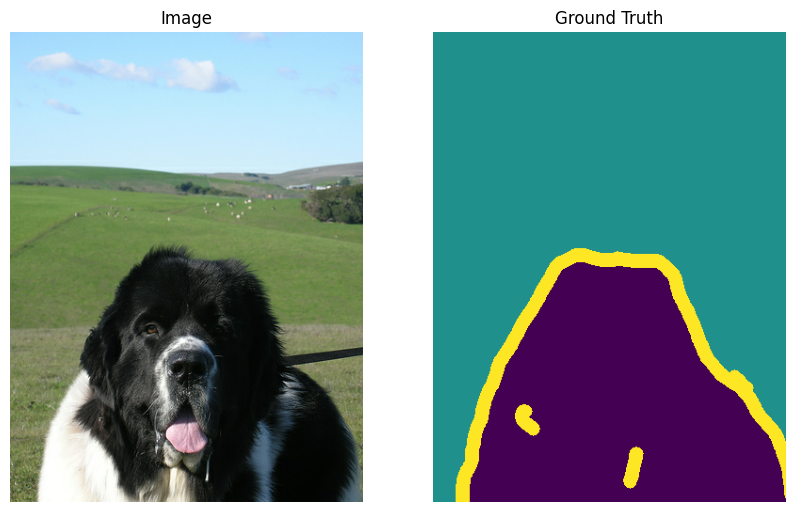

(500, 375, 3)
tf.Tensor([1], shape=(1,), dtype=uint8)


In [6]:
print(species[sample['species']]+' - '+classes[sample['label']])

fig, imgw = plt.subplots(1,2,figsize=(10,10))

imgw[0].set_title('Image')
imgw[0].axis('off')
imgw[0].imshow(sample['image'])
imgw[1].set_title('Ground Truth')
imgw[1].axis('off')
imgw[1].imshow(sample['segmentation_mask'][...,0])

plt.show()

h,w,c = sample['image'].shape
print(sample['image'].shape)
print(sample['segmentation_mask'][h//2][w//2]) # object: 1, background: 2, outline: 3

### Build input data pipelines

In semantic segmentation, class imbalance between object, background, and boundary pixels can degrade training. To address this, **sample weights** are used to adjust the loss contribution of each pixel based on its class, giving higher weight to underrepresented classes such as boundaries. This is conceptually related to the boundary-aware weighting strategy in Eq. (7.27), where $w(x)$ increases the loss near cell boundaries to encourage precise boundary learning.

In this implementation, a per-pixel sample weight tensor is constructed by mapping each class label to its corresponding weight using `tf.gather`, and this tensor is passed as the third element of the dataset tuple `(image, label, sample_weight)` to `Model.fit()`.

In [ ]:
# Oxford-IIIT Pet dataset fields:
#   'image': Image(shape=(None, None, 3), dtype=tf.uint8)
#   'segmentation_mask': Image(shape=(None, None, 1), dtype=tf.uint8)
#     mask values: 1 = object (pet), 2 = background, 3 = outline (boundary)

def tfds_augmtd_4_UNET(element):
    """Preprocess and augment a single dataset element for U-Net training."""

    # Normalize pixel values to [0, 1]
    image = element['image'] / 255
    # Resize to fixed spatial dimensions (128x128)
    image = tf.image.resize(image, [128, 128], method='bilinear', preserve_aspect_ratio=False)

    # Shift mask labels from {1,2,3} to {0,1,2} for zero-indexed class labels
    label = tf.cast(element['segmentation_mask'], dtype=tf.float32) - 1
    # Resize mask with nearest-neighbor to preserve discrete labels
    label = tf.image.resize(label, [128, 128], method='nearest', preserve_aspect_ratio=False)

    # Random horizontal flip for data augmentation
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        label = tf.image.flip_left_right(label)

    return image, label

def gen_sample_weight(image, label):
    """Generate per-pixel sample weights based on class membership.

    Assigns higher weight to boundary (outline) pixels to improve
    boundary prediction, inspired by the weighting strategy in Eq. (7.27).
    """

    ### START CODE HERE ###

    # Define per-class weights: object=1.0, background=1.0, outline=2.0
    # Higher weight on outline encourages the model to learn boundaries
    class_weight = tf.constant([...])
    # Normalize so that weights sum to 1.0
    class_weight = None

    # Map each pixel's class label to its weight using tf.gather
    # label has shape (H, W, 1) with integer class indices
    sample_weight = None

    ### END CODE HERE ###
    
    return image, label, sample_weight

In [8]:
label = tf.convert_to_tensor([0,0])
prediction = tf.convert_to_tensor([[-3., 0], [-3, 0]])
sample_weight = tf.convert_to_tensor([1, 10])

loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True,
                            reduction=keras.losses.Reduction.NONE)
loss(label, prediction, sample_weight).numpy()

array([ 3.0485873, 30.485874 ], dtype=float32)

In [9]:
n_batch = 64

# Training data: preprocess, augment, add sample weights, shuffle, batch
dataset = ds_train.map(tfds_augmtd_4_UNET, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.map(gen_sample_weight)
dataset = dataset.shuffle(buffer_size = 256).batch(batch_size=n_batch)

# Validation data: same pipeline as training
valiset = ds_val.map(tfds_augmtd_4_UNET, num_parallel_calls=tf.data.AUTOTUNE)
valiset = valiset.map(gen_sample_weight)
valiset = valiset.shuffle(buffer_size = 256).batch(batch_size=n_batch)

# Test data: preprocess only (no sample weights needed for evaluation)
testset = ds_test.map(tfds_augmtd_4_UNET, num_parallel_calls=tf.data.AUTOTUNE)
testset = testset.shuffle(buffer_size = 256).batch(batch_size=n_batch)

## Build the U-Net model with Keras Functional API

The U-Net architecture (Section 7.7, Figure 7.10) consists of three parts:
- **Encoder (contracting path):** Repeated application of ConvBlock followed by 2×2 max pooling for downsampling. Channel depth doubles at each stage (64 → 128 → 256 → 512).
- **Bottleneck:** A ConvBlock at the lowest resolution (1024 channels) that captures the most abstract representation.
- **Decoder (expanding path):** 2×2 transposed convolution for upsampling, concatenation with the corresponding encoder feature map (skip connection), followed by a ConvBlock. Channel depth is halved at each stage.

The final 1×1 convolution with softmax activation produces per-pixel class probabilities for 3 classes (object, background, outline).

#### Define ConvBlock: two consecutive convolution layers

Each ConvBlock consists of two 3×3 convolution layers, each followed by batch normalization and ReLU activation (Section 7.7, Figure 7.10). He initialization is used for the convolution kernels (Section 4.4). This implementation uses `padding='same'` to preserve spatial dimensions, unlike the original U-Net which used valid (unpadded) convolutions.

In [ ]:
def ConvBlock(X, channel_size):

   ### START CODE HERE ###

   # Apply 3x3 Conv2D with He initialization, no activation yet (Section 7.7)
   X = keras.layers.Conv2D(...)(X)
   # Batch normalization before activation (Section 4.7)
   X = keras.layers....
   # ReLU activation (Section 3.3)
   X = keras.layers....

   # Repeat: second 3x3 Conv2D + BatchNorm + ReLU
   X = keras.layers.Conv2D(...)(X)
   ...
   
   ### END CODE HERE ###

   return X

#### Build the entire U-Net model

Construct the encoder–decoder architecture with skip connections. Variables `X1`–`X4` store encoder feature maps to be concatenated with decoder outputs via skip connections (Section 7.7, Figure 7.10).

In [ ]:
unet_inputs = keras.Input(shape=(128, 128, 3))

### START CODE HERE ###

# ---- Encoder: contracting path (Section 7.7) ----

# Stage 1: ConvBlock (64 ch) → save X1 for skip connection → MaxPool 2x2
X1 = None
X = None

# Stage 2: ConvBlock (128 ch) → save X2 for skip connection → MaxPool 2x2
X2 = None
X = None

# Stage 3: ConvBlock (256 ch) → save X3 for skip connection → MaxPool 2x2
X3 = None
X = None

# Stage 4: ConvBlock (512 ch) → save X4 for skip connection → MaxPool 2x2
X4 = None
X = None

# ---- Bottleneck (Section 7.7) ----
X = None

# ---- Decoder: expanding path with skip connections (Section 7.7) ----

# Stage 4: Upsample via 2x2 transposed convolution → concatenate with X4 → ConvBlock
X = keras.layers.Conv2DTranspose(...)(X)
X = keras.layers.Concatenate...
X = None

# Stage 3: Upsample → concatenate with X3 → ConvBlock
X = None
X = None
X = None

# Stage 2: Upsample → concatenate with X2 → ConvBlock
X = None
X = None
X = None

# Stage 1: Upsample → concatenate with X1 → ConvBlock
X = None
X = None
X = None

# ---- Output layer: 1x1 convolution for pixel-wise classification (Section 7.7) ----
# 3 output channels (object, background, outline) with softmax activation
unet_outputs = None

### END CODE HERE ###

# Combine into a Keras Model
UNET = keras.Model(inputs=unet_inputs, outputs=unet_outputs)

In [20]:
import graphviz
import pydot

In [25]:
UNET.summary()

with open('UNETsummary.txt','w+') as f:
    UNET.summary(print_fn=lambda x: f.write(x + '\n'))
    f.close()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,427 (118.47 MB)

 Trainable params: 31,043,651 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

### Train the model

In [26]:
# Compile with Adam optimizer and sparse categorical cross-entropy loss
opt = keras.optimizers.Adam()
UNET.compile(optimizer=opt, loss='sparse_categorical_crossentropy', weighted_metrics=['accuracy'], jit_compile=False)

In [27]:
from tqdm.keras import TqdmCallback

n_epochs = 10

# Train the U-Net model
results = UNET.fit(dataset, epochs=n_epochs, batch_size=n_batch,
                   validation_data=valiset, validation_batch_size=n_batch,
                   verbose=0, callbacks=[TqdmCallback(verbose=2)] )

0epoch [00:00, ?epoch/s]

  0%|          | 0.00/58.0 [00:00<?, ?batch/s]

  0%|          | 0.00/58.0 [00:00<?, ?batch/s]

  0%|          | 0.00/58.0 [00:00<?, ?batch/s]

  0%|          | 0.00/58.0 [00:00<?, ?batch/s]

...

  0%|          | 0.00/58.0 [00:00<?, ?batch/s]

  0%|          | 0.00/58.0 [00:00<?, ?batch/s]

  0%|          | 0.00/58.0 [00:00<?, ?batch/s]

  0%|          | 0.00/58.0 [00:00<?, ?batch/s]

  0%|          | 0.00/58.0 [00:00<?, ?batch/s]

### Plot convergence graph

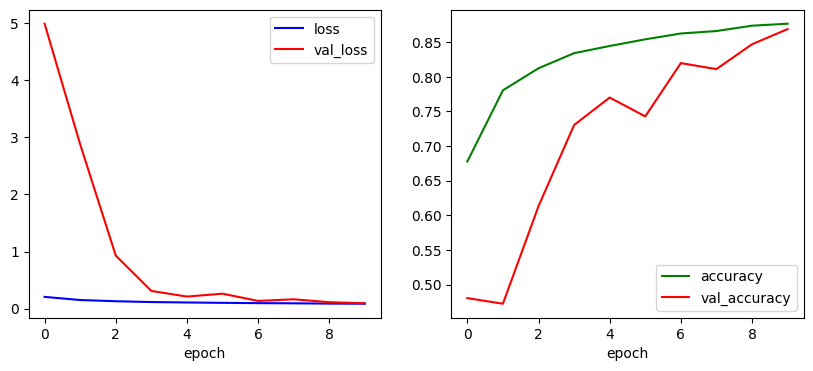

In [28]:
# Plot training and validation loss/accuracy curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(results.history['loss'], 'b-', label='loss')
plt.plot(results.history['val_loss'], 'r-', label='val_loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(results.history['accuracy'], 'g-', label='accuracy')
plt.plot(results.history['val_accuracy'], 'r-', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()

plt.show()

### Evaluate model performance on test set

In [29]:
UNET.evaluate(testset)

29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 578ms/step - accuracy: 0.8872 - loss: 0.2894


[0.28937283158302307, 0.8872264623641968]

### Test model with a random sample

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


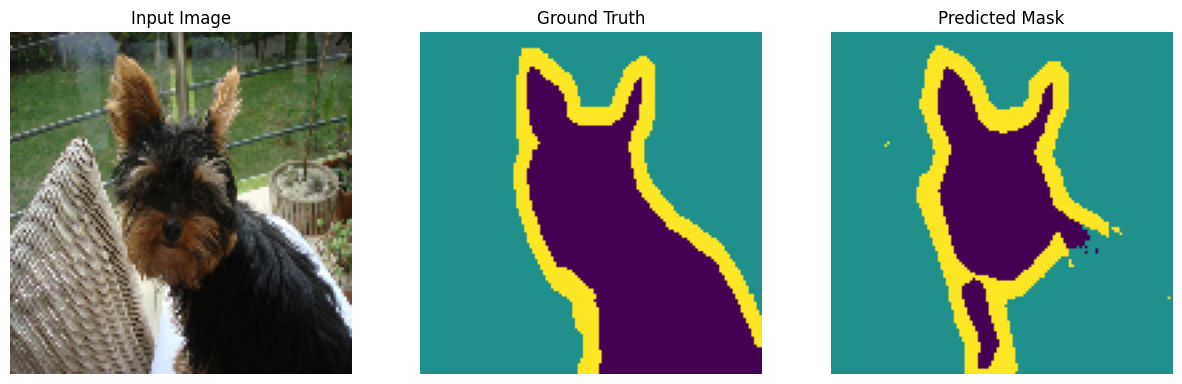

In [30]:
# Select a random test sample and generate prediction
idx = np.random.randint(n_test-1)

for element in ds_test.skip(idx).take(1):
    image, mask = tfds_augmtd_4_UNET(element)
    image = tf.expand_dims(image, axis=0)
    mask = tf.expand_dims(mask, axis=0)

# Predict segmentation mask and take argmax for class assignment
p_mask = UNET.predict(image)
p_mask = tf.argmax(p_mask, axis=-1)
p_mask = p_mask[..., tf.newaxis]

# Display input image, ground truth, and predicted mask side by side
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title('Input Image')
plt.imshow(image[0])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Ground Truth')
plt.imshow(mask[0][...,0])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Predicted Mask')
plt.imshow(p_mask[0][...,0])
plt.axis('off')

plt.show()

(c) 2026 S. W. Lee